# Notebook 02 — Data Cleaning and Preprocessing

## Objective

This notebook prepares the combined NHANES dataset for exploratory data analysis
and machine-learning regression modelling.

The primary outcome is:

- **BMI (BMXBMI):** continuous outcome for regression modelling.

The analysis is restricted to adults aged 18 years and older. Data cleaning
includes handling NHANES special response codes, assessing missing data,
examining potential outliers, and creating interpretable categorical variables.

A derived obesity variable (BMI ≥ 30 kg/m²) is retained for descriptive analyses,
but it is not used as a predictor in the BMI regression models.

### Step 1. Import Libraries, Load and Inspect the Dataset

The merged NHANES dataset containing the selected variables from three survey
cycles was loaded and inspected for dimensions, data types and general structure.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../outputs/Final_edited.csv")

In [2]:
# Check data size
df.shape

(29400, 29)

In [3]:
# Look at the first few rows
df.head()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,DMDMARTL,INDFMPIR,BMXBMI,BMXWAIST,BPXSY1,...,DUQ200,DIQ010,DIQ160,MCQ160A,MCQ160B,MCQ160C,MCQ160E,MCQ160F,DPQ020,WHQ030
0,73557.0,69.0,1.0,4.0,3.0,4.0,0.84,26.7,100.0,122.0,...,NaN,1.0,NaN,1.0,2.0,2.0,2.0,1.0,5.397605e-79,3.0
1,73558.0,54.0,1.0,3.0,3.0,1.0,1.78,28.6,107.6,156.0,...,1.0,1.0,NaN,2.0,2.0,2.0,2.0,2.0,5.397605e-79,3.0
2,73559.0,72.0,1.0,3.0,4.0,1.0,4.51,28.9,109.2,140.0,...,NaN,1.0,NaN,2.0,2.0,2.0,2.0,2.0,5.397605e-79,3.0
3,73560.0,9.0,1.0,3.0,NaN,NaN,2.52,17.1,61.0,108.0,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,73561.0,73.0,2.0,3.0,5.0,1.0,5.00,19.7,NaN,136.0,...,NaN,2.0,2.0,1.0,2.0,2.0,2.0,2.0,1.000000e+00,2.0


In [4]:
# Look at the last few rows
df.tail()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,DMDMARTL,INDFMPIR,BMXBMI,BMXWAIST,BPXSY1,...,DUQ200,DIQ010,DIQ160,MCQ160A,MCQ160B,MCQ160C,MCQ160E,MCQ160F,DPQ020,WHQ030
29395,102952.0,70.0,2.0,6.0,3.0,1.0,0.95,20.0,82.2,136.0,...,NaN,3.0,NaN,2.0,2.0,2.0,2.0,2.0,5.397605e-79,3.0
29396,102953.0,42.0,1.0,1.0,3.0,4.0,NaN,35.8,114.8,124.0,...,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.000000e+00,1.0
29397,102954.0,41.0,2.0,4.0,5.0,5.0,1.18,26.1,86.4,116.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,5.397605e-79,3.0
29398,102955.0,14.0,2.0,4.0,NaN,NaN,2.24,45.6,113.5,114.0,...,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29399,102956.0,38.0,1.0,3.0,4.0,3.0,1.56,36.1,122.0,150.0,...,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,1.000000e+00,1.0


In [5]:
# See all column names
df.columns

Index(['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'DMDMARTL',
       'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'BPXSY1', 'BPXDI1', 'LBDHDD', 'LBXTC',
       'LBXGH', 'SMQ020', 'PAQ605', 'PAQ620', 'PAD680', 'PAQ650', 'DUQ200',
       'DIQ010', 'DIQ160', 'MCQ160A', 'MCQ160B', 'MCQ160C', 'MCQ160E',
       'MCQ160F', 'DPQ020', 'WHQ030'],
      dtype='object')

In [6]:
# Check data types and missing values (general data information)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29400 entries, 0 to 29399
Data columns (total 29 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      29400 non-null  float64
 1   RIDAGEYR  29400 non-null  float64
 2   RIAGENDR  29400 non-null  float64
 3   RIDRETH3  29400 non-null  float64
 4   DMDEDUC2  17057 non-null  float64
 5   DMDMARTL  17057 non-null  float64
 6   INDFMPIR  26332 non-null  float64
 7   BMXBMI    25816 non-null  float64
 8   BMXWAIST  24575 non-null  float64
 9   BPXSY1    20619 non-null  float64
 10  BPXDI1    20619 non-null  float64
 11  LBDHDD    21618 non-null  float64
 12  LBXTC     21618 non-null  float64
 13  LBXGH     19014 non-null  float64
 14  SMQ020    17961 non-null  float64
 15  PAQ605    19970 non-null  float64
 16  PAQ620    19969 non-null  float64
 17  PAD680    19936 non-null  float64
 18  PAQ650    19966 non-null  float64
 19  DUQ200    10329 non-null  float64
 20  DIQ010    28241 non-null  fl

### Step 2. Check Duplicate Participants

SEQN is the unique NHANES participant identifier. Duplicate participant IDs and completely duplicated records were checked before further analysis.

In [7]:
print("Duplicate SEQN:",
      df["SEQN"].duplicated().sum())

print("Duplicate rows:",
      df.duplicated().sum())

Duplicate SEQN: 0
Duplicate rows: 0


No duplicate participant identifiers or completely duplicated records were identified.

### Step 3. Assess Initial Missing Data

Missingness was examined before restricting the study population. Several questionnaires are administered only to particular NHANES age groups, meaning that some missing values may represent structural missingness rather than ordinary non-response.

In [8]:
initial_missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percent": (df.isnull().mean() * 100).round(2)
})

initial_missing.sort_values(
    "Missing_Percent",
    ascending=False
).head(15)

,Missing_Count,Missing_Percent
DUQ200,19071,64.87
DPQ020,13747,46.76
MCQ160F,12343,41.98
DMDEDUC2,12343,41.98
DMDMARTL,12343,41.98
MCQ160E,12343,41.98
MCQ160C,12343,41.98
MCQ160B,12343,41.98
MCQ160A,12343,41.98
SMQ020,11439,38.91


### Step 4. Restrict the Analysis to Adults

The analysis was restricted to participants aged 18 years and older. This population was selected because the project focuses on adult obesity and because several socioeconomic, lifestyle and health questionnaires are not administered to younger participants.

Restricting the population also substantially reduced structural missingness.

In [9]:
df_adults = df[df["RIDAGEYR"] >= 18].copy()

print("Original participants:", len(df))
print("Adult participants:", len(df_adults))

Original participants: 29400
Adult participants: 17961


### Step 5. Clean NHANES Special Response Codes

NHANES uses special numerical codes for responses such as "Refused" and "Don't know". Categorical variables were inspected before recoding to identify unusual or
non-substantive response values. These were converted to missing values where appropriate.

In [10]:
# Categorical variables to inspect
categorical_vars = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTL",
    "SMQ020",
    "DUQ200",
    "DIQ010",
    "DIQ160",
    "MCQ160A",
    "MCQ160B",
    "MCQ160C",
    "MCQ160E",
    "MCQ160F",
    "PAQ605",
    "PAQ620",
    "PAQ650",
    "WHQ030",
    "DPQ020"
]

for col in categorical_vars:
    values = sorted(df_adults[col].dropna().unique())
    values = [float(x) for x in values]
    print(f"{col}: {values}")

RIAGENDR: [1.0, 2.0]
RIDRETH3: [1.0, 2.0, 3.0, 4.0, 6.0, 7.0]
DMDEDUC2: [1.0, 2.0, 3.0, 4.0, 5.0, 7.0, 9.0]
DMDMARTL: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 77.0, 99.0]
SMQ020: [1.0, 2.0, 7.0, 9.0]
DUQ200: [1.0, 2.0, 7.0, 9.0]
DIQ010: [1.0, 2.0, 3.0, 9.0]
DIQ160: [1.0, 2.0, 9.0]
MCQ160A: [1.0, 2.0, 9.0]
MCQ160B: [1.0, 2.0, 9.0]
MCQ160C: [1.0, 2.0, 9.0]
MCQ160E: [1.0, 2.0, 9.0]
MCQ160F: [1.0, 2.0, 9.0]
PAQ605: [1.0, 2.0, 7.0, 9.0]
PAQ620: [1.0, 2.0, 7.0, 9.0]
PAQ650: [1.0, 2.0, 9.0]
WHQ030: [1.0, 2.0, 3.0, 7.0, 9.0]
DPQ020: [5.397605346934028e-79, 1.0, 2.0, 3.0, 7.0, 9.0]


The observed categories was inspected before cleaning them, their meanings were checked against the variable coding, and variable-specific cleaning was applied rather than globally deleting values such as 7 or 9.”

Cleaning was performed at the variable level mainly because the same numerical value had different meanings across NHANES variables. For example, code 7 is a valid race/ethnicity category in RIDRETH3 and was therefore retained.

In [11]:
# Variable-specific invalid/non-response codes
invalid_codes = {
    "DMDEDUC2": [7, 9],
    "DMDMARTL": [77, 99],
    "SMQ020": [7, 9],
    "DUQ200": [7, 9],
    "DIQ010": [7, 9],
    "DIQ160": [7, 9],
    "MCQ160A": [7, 9],
    "MCQ160B": [7, 9],
    "MCQ160C": [7, 9],
    "MCQ160E": [7, 9],
    "MCQ160F": [7, 9],
    "PAQ605": [7, 9],
    "PAQ620": [7, 9],
    "PAQ650": [7, 9],
    "WHQ030": [7, 9]
}

# Replace invalid codes with NaN
for col, codes in invalid_codes.items():
    df_adults[col] = df_adults[col].replace(codes, np.nan)

In [12]:
# Convert the XPT near-zero artefact to the valid response 0
df_adults.loc[df_adults["DPQ020"] < 1e-10, "DPQ020"] = 0

# Convert Refused / Don't know to missing
df_adults["DPQ020"] = df_adults["DPQ020"].replace([7, 9], np.nan)

# Verify cleaning
print(sorted(df_adults["DPQ020"].dropna().unique()))

[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


DPQ020 contained an XPT import artefact where zero values appeared as extremely small numbers. These were restored to 0, while NHANES non-response codes 7 and 9 were converted to missing values (NaN)

### Step 6. Define the Analysis Outcomes

BMI (BMXBMI) is the primary continuous outcome for regression modelling. Participants without a measured BMI were excluded rather than having the outcome imputed.

A binary obesity variable was subsequently created for descriptive analyses:

- **0 = Not obese:** BMI < 30 kg/m²
- **1 = Obese:** BMI ≥ 30 kg/m²

In [13]:
# Remove participants without measured BMI
df_adults = df_adults.dropna(
    subset=["BMXBMI"]
).copy()

# Create classification target
df_adults["Obesity"] = (
    df_adults["BMXBMI"] >= 30
).astype(int)

print("Final participants with BMI:",
      len(df_adults))

print("\nObesity number:")
print(df_adults["Obesity"].value_counts())

print("\nObesity percentage:")
print(
    df_adults["Obesity"]
    .value_counts(normalize=True) * 100
)

Final participants with BMI: 16943

Obesity number:
Obesity
0    10309
1     6634
Name: count, dtype: int64

Obesity percentage:
Obesity
0    60.845187
1    39.154813
Name: proportion, dtype: float64


### Step 7. Examine Continuous Variables

Descriptive statistics were used to examine the distributions and ranges of continuous demographic, socioeconomic, anthropometric and clinical variables.

In [14]:
continuous_vars = [
    "RIDAGEYR",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBDHDD",
    "LBXTC",
    "LBXGH",
    "PAD680"
]

df_adults[continuous_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
RIDAGEYR,16943.0,48.301186,18.467534,1.800000e+01,32.00,48.00,63.00,80.0
INDFMPIR,15183.0,2.461317,1.622282,5.397605e-79,1.07,2.04,3.92,5.0
BMXBMI,16943.0,29.321566,7.245840,1.410000e+01,24.20,28.10,32.95,86.2
BMXWAIST,16107.0,99.357497,16.965887,5.550000e+01,87.20,98.00,109.40,177.9
BPXSY1,15547.0,124.353251,18.609290,6.600000e+01,112.00,122.00,134.00,236.0
BPXDI1,15547.0,70.160803,13.080435,5.397605e-79,62.00,70.00,78.00,124.0
LBDHDD,16000.0,53.349812,16.343665,6.000000e+00,42.00,51.00,62.00,226.0
LBXTC,16000.0,188.001563,41.575254,6.900000e+01,160.00,185.00,213.00,813.0
LBXGH,16178.0,5.786506,1.101358,3.500000e+00,5.20,5.50,5.90,17.5
PAD680,16918.0,429.039898,742.211616,5.397605e-79,240.00,360.00,480.00,9999.0


### Step 8. Clean Invalid Continuous Values

Continuous variables were inspected for invalid response codes and near-zero numerical artefacts observed after XPT import. Invalid values were converted to missing values, while clinically plausible extreme measurements were retained.

In [15]:
# Correct XPT-import artefacts
for col in ["INDFMPIR", "BPXDI1", "PAD680"]:
    df_adults.loc[
        df_adults[col] < 1e-10,
        col
    ] = np.nan

# Remove special PAD680 response codes
df_adults["PAD680"] = df_adults["PAD680"].replace(
    [7777, 9999],
    np.nan
)

# Verify cleaning
df_adults[
    ["INDFMPIR", "BPXDI1", "PAD680"]
].agg(["min", "max"])

,INDFMPIR,BPXDI1,PAD680
min,0.01,4.0,1.0
max,5.00,124.0,1380.0


### Step 9. Examine Distributions and Potential Outliers

Histograms and boxplots were used to assess the distributions of continuous variables. Potential outliers were subsequently identified using the interquartile range (IQR) method.

In [16]:
# Continuous variable labels: real name + NHANES code

variable_labels = {
    "RIDAGEYR": "Age (RIDAGEYR)",
    "INDFMPIR": "Income-to-Poverty Ratio (INDFMPIR)",
    "BMXBMI": "Body Mass Index (BMXBMI)",
    "BMXWAIST": "Waist Circumference (BMXWAIST)",
    "BPXSY1": "Systolic Blood Pressure (BPXSY1)",
    "BPXDI1": "Diastolic Blood Pressure (BPXDI1)",
    "LBDHDD": "HDL Cholesterol (LBDHDD)",
    "LBXTC": "Total Cholesterol (LBXTC)",
    "LBXGH": "HbA1c (LBXGH)",
    "PAD680": "Sedentary Time (PAD680)"
}

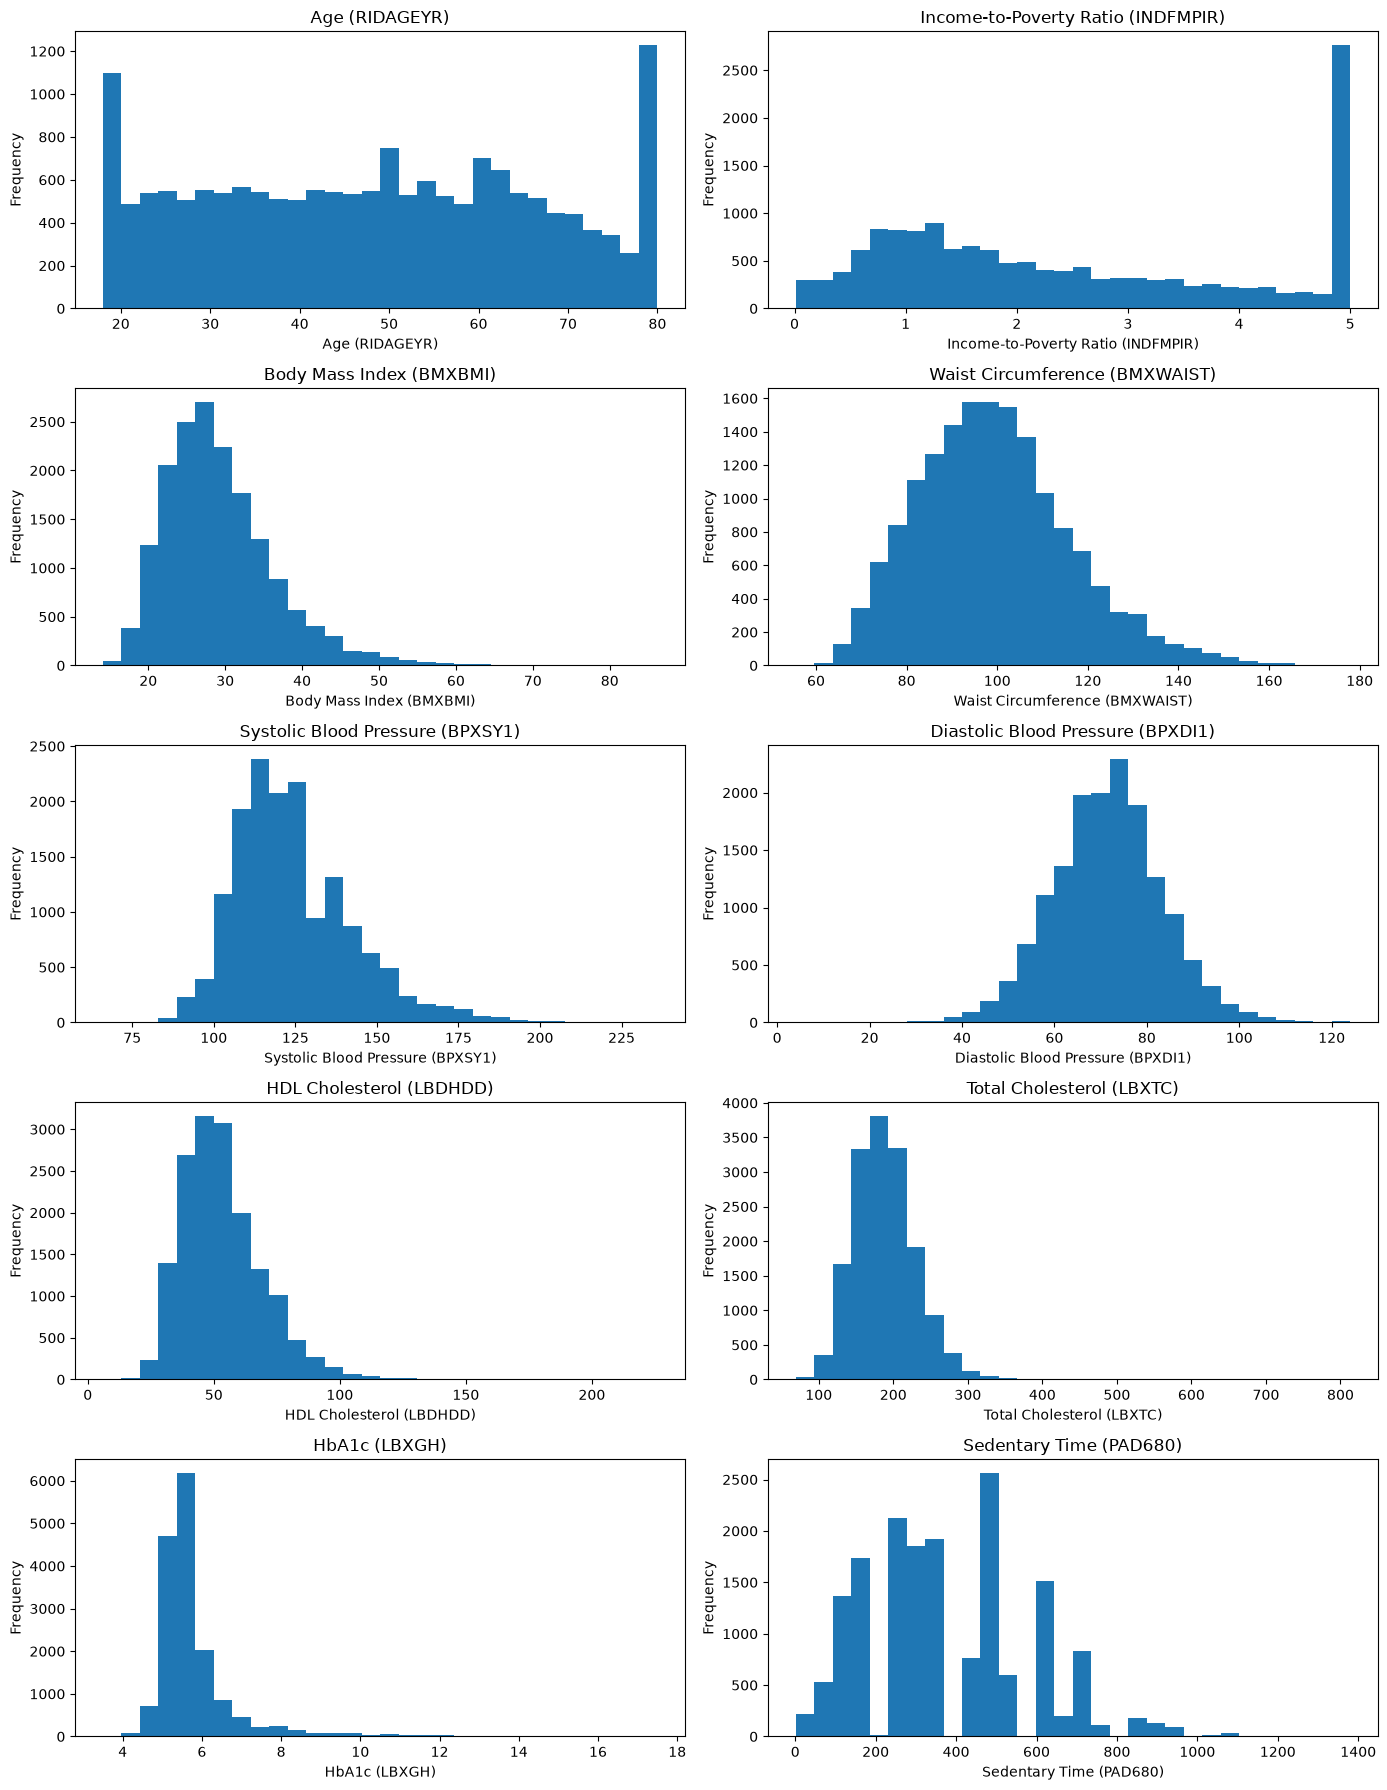

In [17]:
# Histogram
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for ax, col in zip(axes, variable_labels):
    ax.hist(df_adults[col].dropna(), bins=30)
    ax.set_title(variable_labels[col])
    ax.set_xlabel(variable_labels[col])
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

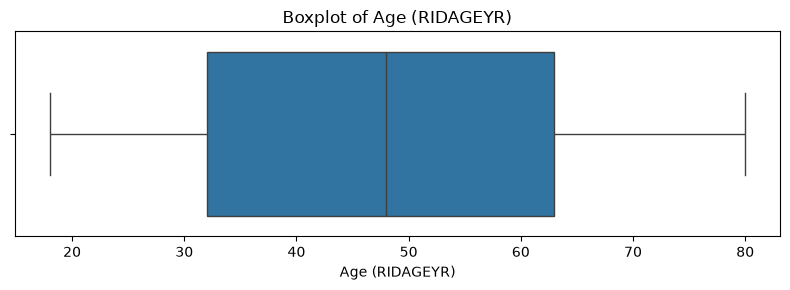

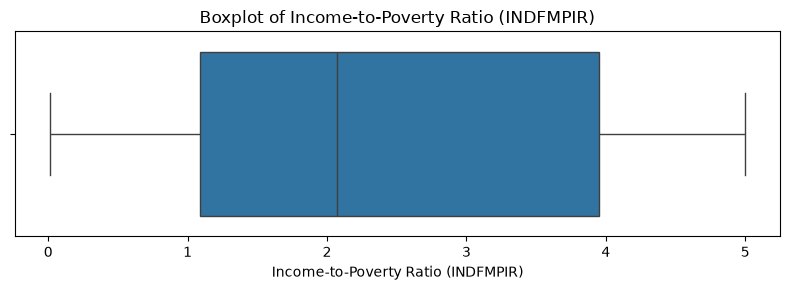

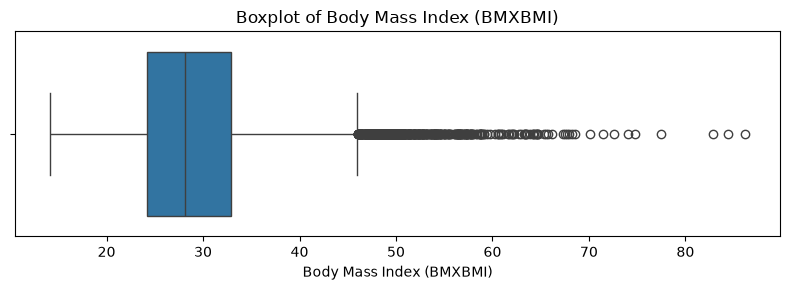

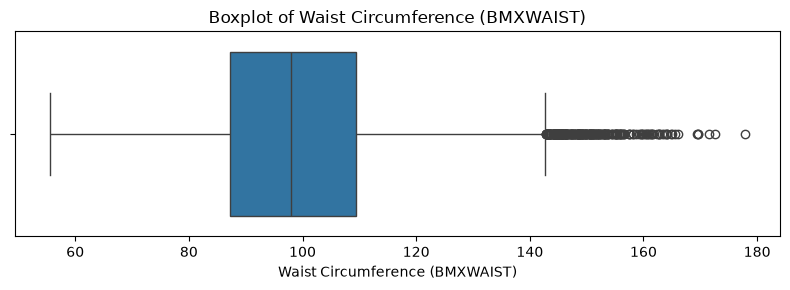

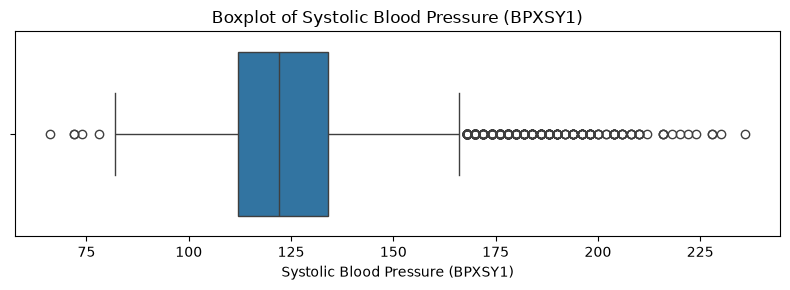

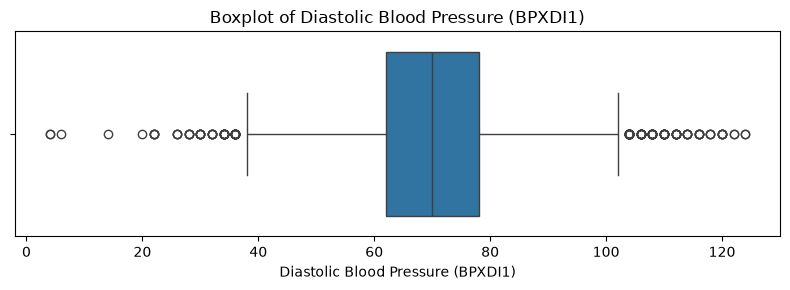

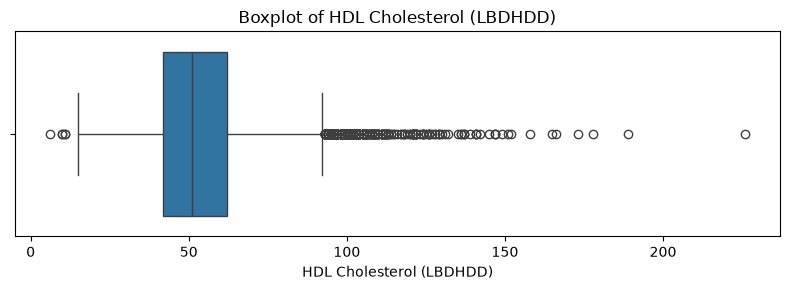

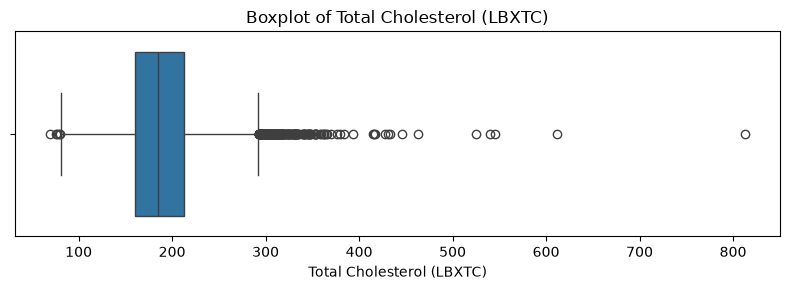

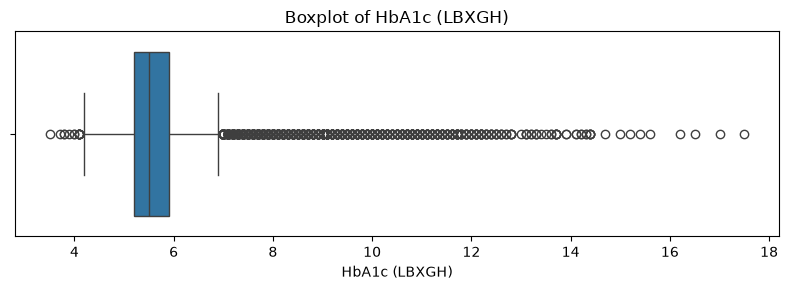

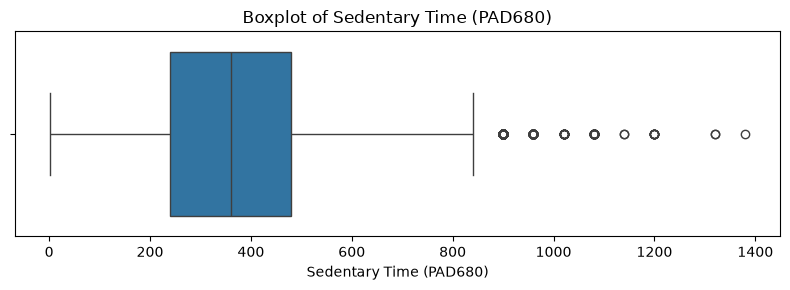

In [18]:
# Boxplot
for col, label in variable_labels.items():
    plt.figure(figsize=(8, 3))

    sns.boxplot(x=df_adults[col])

    plt.title(f"Boxplot of {label}")
    plt.xlabel(label)

    plt.tight_layout()
    plt.show()

### Step 10. Quantify Potential Outliers

Potential outliers were identified using the IQR rule (values below
Q1 − 1.5×IQR or above Q3 + 1.5×IQR).

These observations were flagged for assessment rather than automatically
removed. Extreme BMI, HbA1c, blood pressure and cholesterol measurements can
represent genuine clinical conditions. Removing them could therefore remove
clinically important observations and bias the analysis.

In [19]:
# Identify potential outliers using the IQR method
outlier_summary = []

for col in continuous_vars:
    
    Q1 = df_adults[col].quantile(0.25)
    Q3 = df_adults[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_adults[
        (df_adults[col] < lower_bound) |
        (df_adults[col] > upper_bound)
    ]
    
    outlier_summary.append({
        "Variable": variable_labels[col],
        "Lower_Bound": round(lower_bound, 2),
        "Upper_Bound": round(upper_bound, 2),
        "Outlier_Count": len(outliers),
        "Outlier_Percent": round(len(outliers) / len(df_adults) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary[
    ["Variable",
     "Outlier_Count",
     "Outlier_Percent"]
]

,Variable,Outlier_Count,Outlier_Percent
0,Age (RIDAGEYR),0,0.00
1,Income-to-Poverty Ratio (INDFMPIR),0,0.00
2,Body Mass Index (BMXBMI),488,2.88
3,Waist Circumference (BMXWAIST),257,1.52
4,Systolic Blood Pressure (BPXSY1),465,2.74
5,Diastolic Blood Pressure (BPXDI1),166,0.98
6,HDL Cholesterol (LBDHDD),358,2.11
7,Total Cholesterol (LBXTC),211,1.25
8,HbA1c (LBXGH),1379,8.14
9,Sedentary Time (PAD680),294,1.74


The IQR method identified potential outliers in several clinical variables, particularly HbA1c. These observations were retained because values outside the IQR thresholds are not necessarily erroneous and the observed extremes were considered clinically plausible. Only known invalid response codes and identified numerical artefacts were treated as missing.

### Step 11. Assess Final Missingness

Missingness was reassessed following population restriction and data cleaning. 

Most predictors had relatively modest missingness, although drug-use history (DUQ200) had substantially higher missingness.

Missing continuous and categorical predictor values were not imputed at this stage. Imputation was incorporated into the machine-learning preprocessing pipeline and fitted using training data only, reducing the risk of data leakage.

For descriptive analysis, missing drug-use responses were represented as an “Unknown” category rather than being interpreted as either drug use or non-use. In the machine-learning pipeline, missing categorical predictor values were handled using the specified categorical imputation procedure.

In [20]:
final_missing = pd.DataFrame({
    "Missing_Count": df_adults.isnull().sum(),
    "Missing_Percent":
        (df_adults.isnull().mean() * 100).round(2)
})

final_missing.sort_values(
    "Missing_Percent",
    ascending=False
).head(15)

,Missing_Count,Missing_Percent
DUQ200,6713,39.62
DIQ160,2782,16.42
INDFMPIR,1916,11.31
BPXDI1,1487,8.78
DPQ020,1471,8.68
BPXSY1,1396,8.24
LBXTC,943,5.57
LBDHDD,943,5.57
MCQ160C,896,5.29
MCQ160A,877,5.18


### Step 12. Create Interpretable Variables and Save the Cleaned Dataset

Descriptive labels were created for selected NHANES categorical variables to improve interpretation of tables and visualisations in subsequent analyses.

The original coded variables were retained alongside the descriptive versions for traceability. Duplicate representations of the same information will not be entered simultaneously into machine-learning models.

In [21]:
# Recode the categorical variables
# Sex
df_adults["Sex"] = df_adults["RIAGENDR"].map({
    1: "Male",
    2: "Female"
})

# Race/Ethnicity
df_adults["Race_Ethnicity"] = df_adults["RIDRETH3"].map({
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other/Multi-Racial"
})

# Education
df_adults["Education"] = df_adults["DMDEDUC2"].map({
    1: "Less than 9th grade",
    2: "9-11th grade",
    3: "High school/GED",
    4: "Some college/AA degree",
    5: "College graduate or above"
})

# Marital status
df_adults["Marital_Status"] = df_adults["DMDMARTL"].map({
    1: "Married",
    2: "Widowed",
    3: "Divorced",
    4: "Separated",
    5: "Never married",
    6: "Living with partner"
})

# Smoking
df_adults["Smoked_100_Cigarettes"] = df_adults["SMQ020"].map({
    1: "Yes",
    2: "No"
})

# Diabetes
df_adults["Diabetes"] = df_adults["DIQ010"].map({
    1: "Yes",
    2: "No",
    3: "Borderline"
})

# Prediabetes
df_adults["Prediabetes"] = df_adults["DIQ160"].map({
    1: "Yes",
    2: "No"
})

# Medical conditions
medical_vars = {
    "MCQ160A": "Arthritis",
    "MCQ160B": "Congestive_Heart_Failure",
    "MCQ160C": "Coronary_Heart_Disease",
    "MCQ160E": "Heart_Attack",
    "MCQ160F": "Stroke"
}

for code, new_name in medical_vars.items():
    df_adults[new_name] = df_adults[code].map({
        1: "Yes",
        2: "No"
    })

# Physical activity
df_adults["Vigorous_Work_Activity"] = df_adults["PAQ605"].map({
    1: "Yes",
    2: "No"
})

df_adults["Moderate_Work_Activity"] = df_adults["PAQ620"].map({
    1: "Yes",
    2: "No"
})

df_adults["Vigorous_Recreational_Activity"] = df_adults["PAQ650"].map({
    1: "Yes",
    2: "No"
})

# Weight history
df_adults["Weight_Change_Intent"] = df_adults["WHQ030"].map({
    1: "Yes",
    2: "No",
    3: "Not trying"
})

# Depression symptom
df_adults["Depressed_Hopeless"] = df_adults["DPQ020"].map({
    0: "Not at all",
    1: "Several days",
    2: "More than half the days",
    3: "Nearly every day"
})

# Drug use
df_adults["Drug_Use"] = df_adults["DUQ200"].map({
    1: "Yes",
    2: "No"
}).fillna("Unknown")

Creating new labelled columns rather than overwriting the original NHANES variables was to preserve the original codes for modelling and verification.

In [22]:
# Final quality checks
print("Final dataset shape:", df_adults.shape)

print("Unique participants:",
      df_adults["SEQN"].nunique())

print("Missing BMI:",
      df_adults["BMXBMI"].isna().sum())

print("Missing obesity target:",
      df_adults["Obesity"].isna().sum())

Final dataset shape: (16943, 48)
Unique participants: 16943
Missing BMI: 0
Missing obesity target: 0


In [23]:
# Save cleaned dataset
df_adults.to_csv(
    "../outputs/NHANES_Cleaned_Adults.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


### Summary

The initial combined NHANES dataset contained 29,400 participants and 29 selected variables. After restricting the analysis to adults and excluding participants without measured BMI, the analytical sample contained 16,943 participants.

NHANES special response codes and identified numerical artefacts were cleaned, missingness was assessed, and potential outliers were investigated. Clinically plausible extreme measurements were retained to preserve meaningful variation in the population.

BMI was retained as the continuous regression target. A derived obesity variable (BMI ≥ 30 kg/m²) was retained for descriptive analyses. Descriptive categorical labels were added for interpretability, while the original NHANES coded variables were preserved for traceability and modelling. The cleaned dataset was then saved for exploratory data analysis and machine-learning regression modelling.